<a href="https://colab.research.google.com/github/reighrey19/shiara_INFO4670_Spring2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from google.colab import files
uploaded = files.upload()


data = pd.read_csv('car_purchase_data.csv')
display(data.head())
print('Shape:', data.shape)

Saving car_purchase_data.csv to car_purchase_data.csv


,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


Shape: (400, 5)


### Step 2: Split features and target

In [3]:
X = data[['Age', 'Salary']]
y = data['Purchased']

print('X shape:', X.shape)
print('y distribution:\n', y.value_counts())

X shape: (400, 2)
y distribution:
 Purchased
0    257
1    143
Name: count, dtype: int64


### Step 3: Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=2, random_state=42, stratify=y
)
print('Train size:', X_train.shape[0], ' Test size:', X_test.shape[0])

Train size: 398  Test size: 2


### Step 4: Feature Scaling

In [12]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
print('Scaling complete.')

Scaling complete.


### Step 5: Train Logistic Regression Model

In [14]:
model_2d = LogisticRegression(max_iter=1000)
model_2d.fit(X_train_std, y_train)
print('Model trained.')

Model trained.


### Step 6: Predict and Evaluate

In [15]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print('Accuracy:', acc)
print('\nConfusion Matrix:\n', cm)
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.5

Confusion Matrix:
 [[0 1]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sample

### Step 7: Visualization of Decision Regions

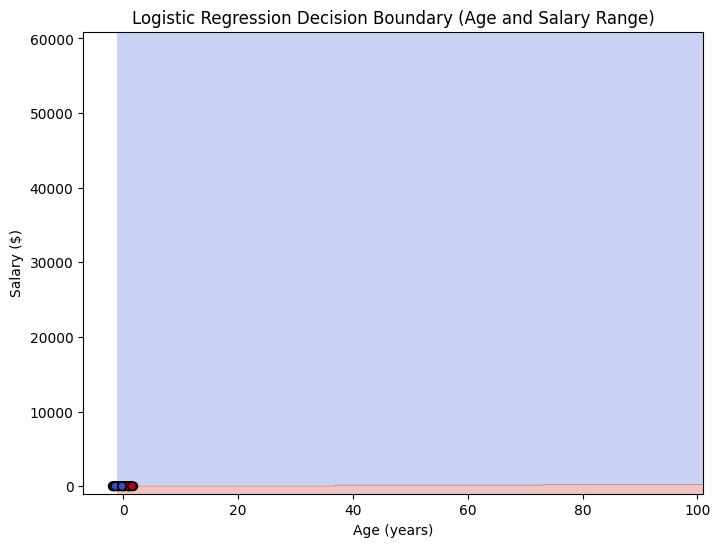

In [19]:
import numpy as np
import matplotlib.pyplot as plt


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


age_min, age_max = 0, 100
salary_min, salary_max = 0, 60000

age_salary_filter_train = (X_train.iloc[:, 0] >= age_min) & (X_train.iloc[:, 0] <= age_max) & (X_train.iloc[:, 1] >= salary_min) & (X_train.iloc[:, 1] <= salary_max)
age_salary_filter_test = (X_test.iloc[:, 0] >= age_min) & (X_test.iloc[:, 0] <= age_max) & (X_test.iloc[:, 1] >= salary_min) & (X_test.iloc[:, 1] <= salary_max)

X_train_filtered = X_train[age_salary_filter_train]
y_train_filtered = y_train[age_salary_filter_train]

X_test_filtered = X_test[age_salary_filter_test]
y_test_filtered = y_test[age_salary_filter_test]

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_filtered.iloc[:, :2])
X_test_std = scaler.transform(X_test_filtered.iloc[:, :2])


model_2d = LogisticRegression(max_iter=1000)
model_2d.fit(X_train_std, y_train_filtered)


x1_min, x1_max = age_min - 1, age_max + 1
x2_min, x2_max = salary_min - 1000, salary_max + 1000

X1, X2 = np.meshgrid(
    np.arange(start=x1_min, stop=x1_max, step=0.01),
    np.arange(start=x2_min, stop=x2_max, step=100)
)


Z = model_2d.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)


plt.figure(figsize=(8,6))
plt.contourf(X1, X2, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_std[:, 0], X_test_std[:, 1], c=y_test_filtered, edgecolor='k', cmap='coolwarm')
plt.title('Logistic Regression Decision Boundary (Age and Salary Range)')
plt.xlabel('Age (years)')
plt.ylabel('Salary ($)')
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. Logistic regression can be used classification because it provides a boundary that can assist with yes (1) or no (0) questions.

2.